# Logistic Regression on Medical Insurance Dataset

**Objective:** Predict whether a person is a **smoker** (Yes/No) based on features like age, sex, BMI, number of children, region, and medical charges.

**Dataset:** `medical.csv`

**Target Variable:** `smoker` (binary: yes / no)

## 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load the Dataset

In [15]:
df = pd.read_csv(r'../../medical.csv')
print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## 3. Exploratory Data Analysis (EDA)

In [16]:
# Basic info about the dataset
print('=== Dataset Info ===')
print(df.info())
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

=== Statistical Summary ===


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [17]:
# Check for missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== Missing Values ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0


In [18]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 1


In [19]:
# Data types and unique values
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Unique Values per Column ===')
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

=== Data Types ===
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

=== Unique Values per Column ===
age: 47 unique values
sex: 2 unique values
bmi: 548 unique values
children: 6 unique values
smoker: 2 unique values
region: 4 unique values
charges: 1337 unique values


=== Smoker Distribution ===
smoker
no     1064
yes     274
Name: count, dtype: int64

Percentage:
smoker
no     79.521674
yes    20.478326
Name: proportion, dtype: float64


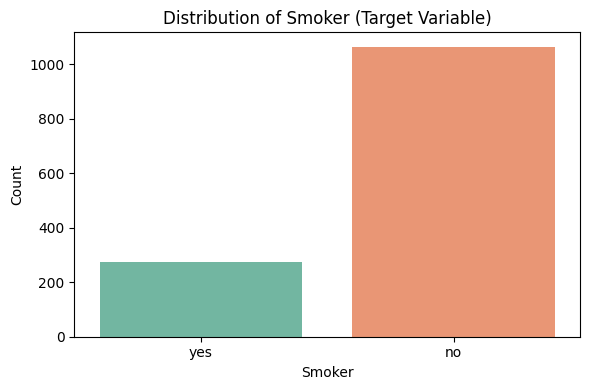

In [20]:
# Target variable distribution
print('=== Smoker Distribution ===')
print(df['smoker'].value_counts())
print(f'\nPercentage:\n{df["smoker"].value_counts(normalize=True) * 100}')

plt.figure(figsize=(6, 4))
sns.countplot(x='smoker', data=df, palette='Set2')
plt.title('Distribution of Smoker (Target Variable)')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

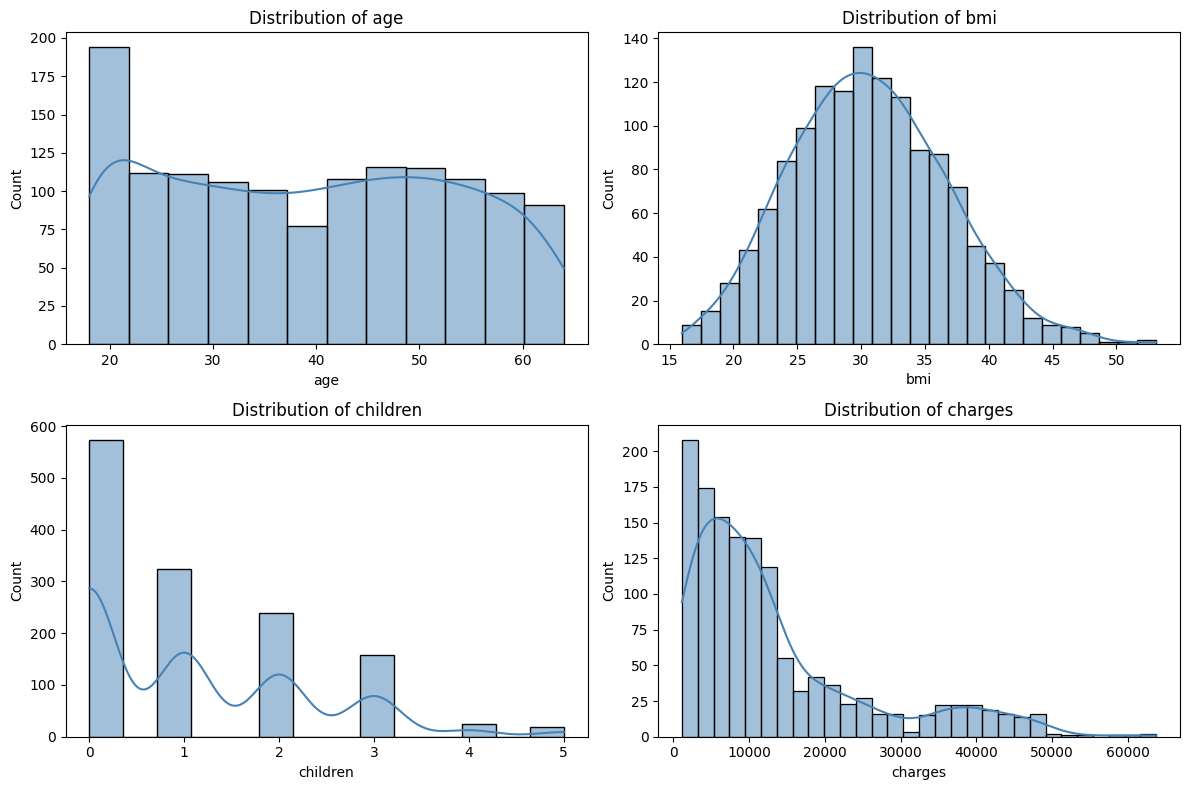

In [21]:
# Distribution of numerical features
numerical_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(numerical_cols):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

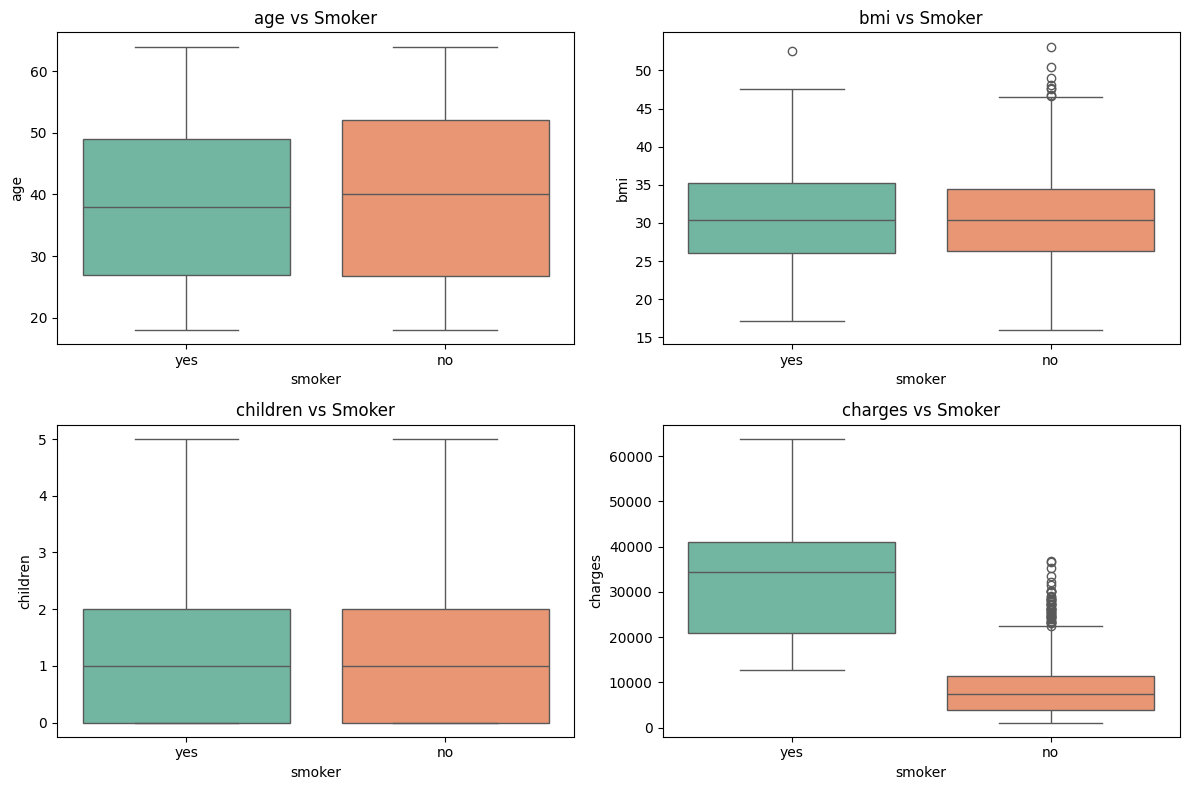

In [22]:
# Boxplots: Numerical features vs Smoker
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(numerical_cols):
    ax = axes[i // 2, i % 2]
    sns.boxplot(x='smoker', y=col, data=df, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Smoker')
plt.tight_layout()
plt.show()

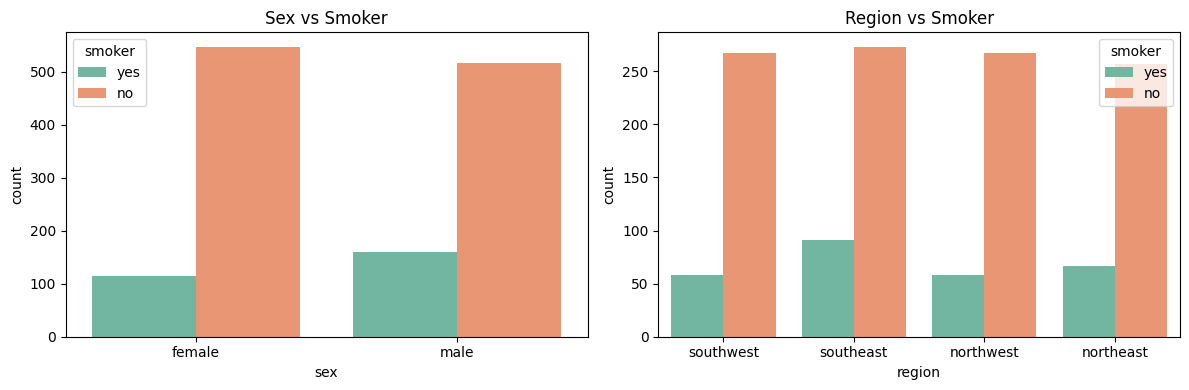

In [23]:
# Categorical features vs Smoker
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='sex', hue='smoker', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Sex vs Smoker')

sns.countplot(x='region', hue='smoker', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Region vs Smoker')

plt.tight_layout()
plt.show()

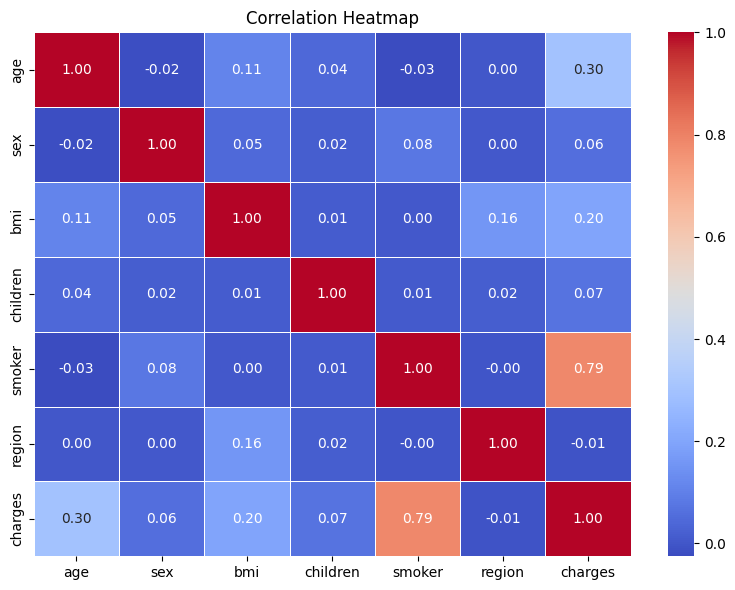

In [24]:
# Correlation heatmap (after encoding)
df_encoded_temp = df.copy()
df_encoded_temp['sex'] = LabelEncoder().fit_transform(df_encoded_temp['sex'])
df_encoded_temp['smoker'] = LabelEncoder().fit_transform(df_encoded_temp['smoker'])
df_encoded_temp['region'] = LabelEncoder().fit_transform(df_encoded_temp['region'])

plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded_temp.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [25]:
# Create a copy for preprocessing
df_processed = df.copy()

# Encode categorical variables using Label Encoding
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df_processed['sex'] = le_sex.fit_transform(df_processed['sex'])
df_processed['smoker'] = le_smoker.fit_transform(df_processed['smoker'])
df_processed['region'] = le_region.fit_transform(df_processed['region'])

print('Encoding Mappings:')
print(f'  sex     : {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}')
print(f'  smoker  : {dict(zip(le_smoker.classes_, le_smoker.transform(le_smoker.classes_)))}')
print(f'  region  : {dict(zip(le_region.classes_, le_region.transform(le_region.classes_)))}')

print('\nProcessed Dataset:')
df_processed.head()

Encoding Mappings:
  sex     : {'female': np.int64(0), 'male': np.int64(1)}
  smoker  : {'no': np.int64(0), 'yes': np.int64(1)}
  region  : {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}

Processed Dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## 5. Define Features (X) and Target (y)

In [26]:
# Features and Target
X = df_processed.drop('smoker', axis=1)
y = df_processed['smoker']

print(f'Features shape: {X.shape}')
print(f'Target shape  : {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')
print(f'\nTarget distribution:\n{y.value_counts()}')

Features shape: (1338, 6)
Target shape  : (1338,)

Feature columns: ['age', 'sex', 'bmi', 'children', 'region', 'charges']

Target distribution:
smoker
0    1064
1     274
Name: count, dtype: int64


## 6. Train-Test Split

In [27]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size : {X_test.shape[0]}')
print(f'\nTraining target distribution:\n{y_train.value_counts()}')
print(f'\nTesting target distribution:\n{y_test.value_counts()}')

Training set size: 1070
Testing set size : 268

Training target distribution:
smoker
0    851
1    219
Name: count, dtype: int64

Testing target distribution:
smoker
0    213
1     55
Name: count, dtype: int64


## 7. Feature Scaling

In [28]:
# Standardize features for better convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling completed!')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape : {X_test_scaled.shape}')

Feature scaling completed!
X_train_scaled shape: (1070, 6)
X_test_scaled shape : (268, 6)


## 8. Train Logistic Regression Model

In [29]:
# Create and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print('Logistic Regression model trained successfully!')
print(f'\nModel Coefficients:')
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print(coeff_df.to_string(index=False))
print(f'\nIntercept: {log_reg.intercept_[0]:.4f}')

Logistic Regression model trained successfully!

Model Coefficients:
 Feature  Coefficient
 charges     3.870556
     sex     0.219113
  region     0.108510
children    -0.229412
     age    -1.153083
     bmi    -1.620289

Intercept: -3.4565


## 9. Predictions

In [30]:
# Make predictions on the test set
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Display first 10 predictions vs actual
results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Probability (Smoker)': y_pred_proba[:10].round(4)
})
results['Actual Label'] = results['Actual'].map({0: 'No', 1: 'Yes'})
results['Predicted Label'] = results['Predicted'].map({0: 'No', 1: 'Yes'})
print('First 10 Predictions vs Actual:')
results

First 10 Predictions vs Actual:


,Actual,Predicted,Probability (Smoker),Actual Label,Predicted Label
0,0,0,0.0072,No,No
1,0,0,0.0073,No,No
2,0,0,0.0642,No,No
3,0,0,0.0007,No,No
4,0,1,0.8890,No,Yes
5,0,0,0.0101,No,No
6,1,1,0.9785,Yes,Yes
7,0,0,0.0378,No,No
8,1,1,0.9956,Yes,Yes
9,0,0,0.0080,No,No


## 10. Model Evaluation

In [31]:
# Accuracy Score
train_accuracy = log_reg.score(X_train_scaled, y_train)
test_accuracy = accuracy_score(y_test, y_pred)

print(f'Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)')
print(f'Testing Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

Training Accuracy: 0.9561 (95.61%)
Testing Accuracy : 0.9776 (97.76%)


In [32]:
# Classification Report
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Non-Smoker (0)', 'Smoker (1)']))

=== Classification Report ===
                precision    recall  f1-score   support

Non-Smoker (0)       1.00      0.98      0.99       213
    Smoker (1)       0.92      0.98      0.95        55

      accuracy                           0.98       268
     macro avg       0.96      0.98      0.97       268
  weighted avg       0.98      0.98      0.98       268



=== Confusion Matrix ===
[[208   5]
 [  1  54]]


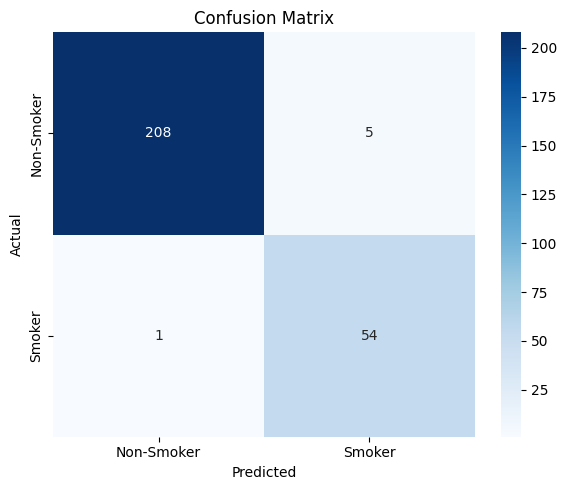


True Negatives  (TN): 208
False Positives (FP): 5
False Negatives (FN): 1
True Positives  (TP): 54


In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print('=== Confusion Matrix ===')
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Smoker', 'Smoker'],
            yticklabels=['Non-Smoker', 'Smoker'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()
print(f'\nTrue Negatives  (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives  (TP): {tp}')

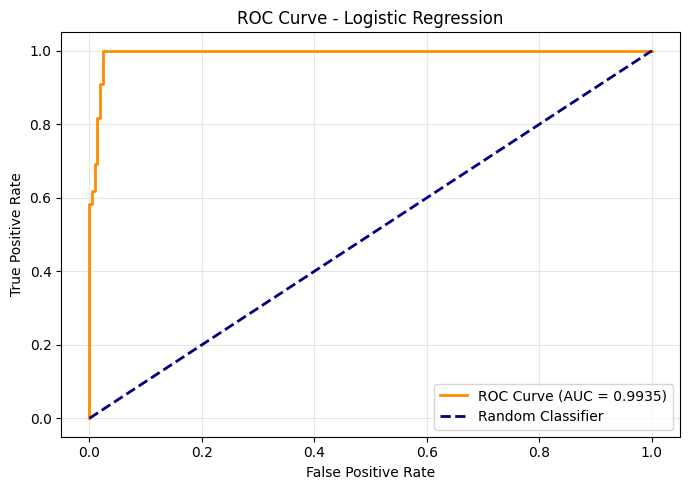

AUC Score: 0.9935


In [34]:
# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC Score: {auc_score:.4f}')

## 11. Feature Importance Visualization

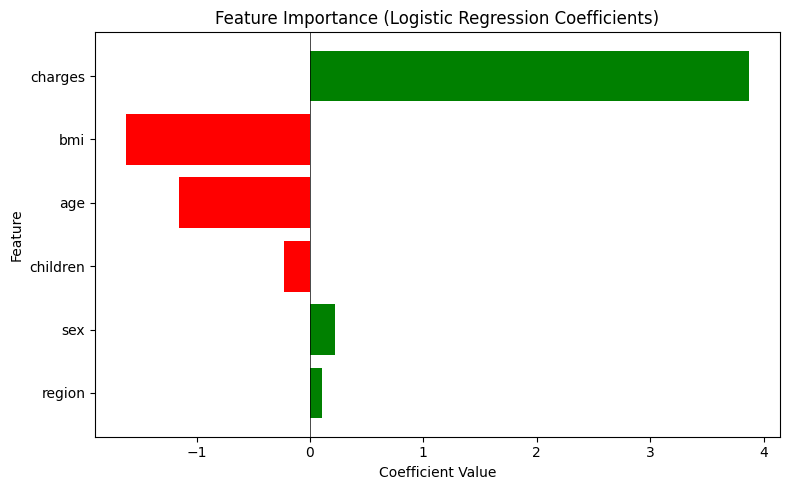

In [35]:
# Feature importance based on model coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Abs_Coefficient': np.abs(log_reg.coef_[0])
}).sort_values(by='Abs_Coefficient', ascending=True)

plt.figure(figsize=(8, 5))
colors = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 12. Summary & Conclusion

In [36]:
print('=' * 60)
print('       LOGISTIC REGRESSION MODEL SUMMARY')
print('=' * 60)
print(f'  Dataset              : medical.csv')
print(f'  Total Samples        : {df.shape[0]}')
print(f'  Features Used        : {list(X.columns)}')
print(f'  Target Variable      : smoker (0 = No, 1 = Yes)')
print(f'  Train / Test Split   : 80% / 20%')
print(f'  Training Accuracy    : {train_accuracy*100:.2f}%')
print(f'  Testing Accuracy     : {test_accuracy*100:.2f}%')
print(f'  AUC Score            : {auc_score:.4f}')
print(f'  True Positives       : {tp}')
print(f'  True Negatives       : {tn}')
print(f'  False Positives      : {fp}')
print(f'  False Negatives      : {fn}')
print('=' * 60)
print('\nConclusion:')
print('The Logistic Regression model was trained to predict smoker')
print('status from the medical insurance dataset. The model uses')
print('age, sex, BMI, children, region, and charges as features.')
print(f'It achieved a testing accuracy of {test_accuracy*100:.2f}% and')
print(f'an AUC score of {auc_score:.4f}, indicating good')
print('discriminative ability between smokers and non-smokers.')

       LOGISTIC REGRESSION MODEL SUMMARY
  Dataset              : medical.csv
  Total Samples        : 1338
  Features Used        : ['age', 'sex', 'bmi', 'children', 'region', 'charges']
  Target Variable      : smoker (0 = No, 1 = Yes)
  Train / Test Split   : 80% / 20%
  Training Accuracy    : 95.61%
  Testing Accuracy     : 97.76%
  AUC Score            : 0.9935
  True Positives       : 54
  True Negatives       : 208
  False Positives      : 5
  False Negatives      : 1

Conclusion:
The Logistic Regression model was trained to predict smoker
status from the medical insurance dataset. The model uses
age, sex, BMI, children, region, and charges as features.
It achieved a testing accuracy of 97.76% and
an AUC score of 0.9935, indicating good
discriminative ability between smokers and non-smokers.
